# 🗂️ MINI-PROJETO AVALIATIVO - Módulo 1 — Análise Exploratória de Dados: Base Varejo
**Contextualização**

Você está desenvolvendo uma Análise Exploratória de Dados (AED) aplicada ao varejo para aprender como transformar dados brutos em informações úteis.

A base “Varejo” contém registros reais de compras (datas, clientes, produtos, categorias e valores). Aprender a verificar qualidade, limpar e sumarizar esses dados é uma habilidade prática essencial para quem trabalha com BI e Visualização de Dados.
Neste mini-projeto você vai praticar tarefas comuns no trabalho: identificar problemas nos dados (valores nulos, tipos incorretos, duplicados), tratar esses problemas com ferramentas como pandas e gerar estatísticas  simples e funções de agrupamento, para responder perguntas operacionais (quem compra mais, quais categorias vendem mais, como variam as vendas ao longo do tempo).

O objetivo educacional é que, ao final, você saiba preparar uma base para análises mais avançadas ou para alimentar um dashboard: entender os dados, limpá-los, extrair estatísticas descritivas e comunicar os principais insights de forma objetiva.

---

## 🔧 Importando bibliotecas e funções - setup inicial

In [1]:
# Importar Bibliotecas padrão
import sys
import os
import warnings

# Importar Bibliotecas externas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Importar Funções próprias (utils)
sys.path.append(os.path.abspath(".."))
from utils.funcoes_varejo import padronizar_data

---
## 📂 Bloco 1 — Carregamento e Diagnóstico Inicial

In [2]:
print("=" * 60)
print("BLOCO 1 — CARREGAMENTO E DIAGNÓSTICO INCIAL")
print("=" * 60)

# Carregando os dados
df = pd.read_csv('../data/base_varejo.csv', sep=';')

print(f"Linhas x Colunas: {df.shape[0]} x {df.shape[1]}")
print(f"\nColunas:", df.columns.tolist())
print(f"\nTipos de dados:")
print(df.dtypes)

BLOCO 1 — CARREGAMENTO E DIAGNÓSTICO INCIAL
Linhas x Colunas: 830000 x 14

Colunas: ['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG', 'PR_ID', 'PR_CAT', 'PR_NOME', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

Tipos de dados:
DATA               str
CO_ID            int64
CL_ID            int64
CL_GENERO          str
CL_EC            int64
CL_FHL           int64
CL_SEG             str
PR_ID            int64
PR_CAT             str
PR_NOME            str
Unnamed: 10    float64
Unnamed: 11    float64
Unnamed: 12    float64
Unnamed: 13    float64
dtype: object


---
## 🔁 Bloco 2 — Identificação de Problemas

In [3]:
print("\n" + "=" * 60)
print("BLOCO 2 — IDENTIFICAÇÃO DE PROBLEMAS")
print("=" * 60)

# Nulos por coluna com percentual
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
relatorio_nulos = pd.DataFrame({'Nulos': nulos, '% do total': pct})
print("\nValores nulos por coluna:")
print(relatorio_nulos)

# Colunas 100% nulas (fantasma)
colunas_vazias = nulos[nulos == len(df)].index.tolist()
print(f"\nColunas 100% nulas (fantasma): {colunas_vazias}")

# Duplicatas
print(f"\nDuplicatas totais:", df.duplicated().sum())



BLOCO 2 — IDENTIFICAÇÃO DE PROBLEMAS

Valores nulos por coluna:
              Nulos  % do total
DATA              0        0.00
CO_ID             0        0.00
CL_ID             0        0.00
CL_GENERO         0        0.00
CL_EC             0        0.00
CL_FHL            0        0.00
CL_SEG            0        0.00
PR_ID             0        0.00
PR_CAT            0        0.00
PR_NOME           0        0.00
Unnamed: 10  830000      100.00
Unnamed: 11  830000      100.00
Unnamed: 12  830000      100.00
Unnamed: 13  830000      100.00

Colunas 100% nulas (fantasma): ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

Duplicatas totais: 96553


---
## 🧹 Bloco 3 — Limpeza dos dados

In [4]:
print("\n" + "=" * 60)
print("BLOCO 3 — LIMPEZA DOS DADOS")
print("=" * 60)

# Cópia do DataFrame original para preservar os dados brutos
df_limpo = df.copy()

# Remover colunas inválidas (fantasma)
'''Justificativa: colunas Unnamed são artefatos do CSV (';' extras no cabeçalho)
e não contêm nenhuma informação, por isso foi escolhido remover.'''
df_limpo = df_limpo.drop(columns=['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'])
print(f"Colunas após remoção das fantasma: {df_limpo.shape[1]}")

# Converter coluna DATA para datetime
'''Justificativa: a coluna está como string no formato dd/mm/yyyy e foi convertida
para datetime para permitir operações de data (filtros, extração de mês/ano etc.).'''
df_limpo = padronizar_data(df_limpo, 'DATA')

# Remover duplicatas (linhas 100% idênticas)
'''Justificativa: linhas 100% idênticas indicam registros repetidos no sistema.
Será mantida a primeira ocorrência (keep='first') como registro original.'''
antes = df_limpo.shape[0]
df_limpo = df_limpo.drop_duplicates(keep='first').reset_index(drop=True)
depois = df_limpo.shape[0]
print(f'\nDuplicatas removidas: {antes - depois}')

# Substituir strings que representam nulo por NaN real
'''Justificativa: '#N/D' indica célula sem valor. Convertemos para NaN para que 
o pandas reconheça corretamente como ausente e permita o tratamento adequado nas etapas seguintes.'''
df_limpo['PR_CAT']  = df_limpo['PR_CAT'].replace(['#N/D', 'NULL', 'N/A', ''], np.nan)
df_limpo['PR_NOME'] = df_limpo['PR_NOME'].replace(['#N/D', 'NULL', 'N/A', ''], np.nan)
print(f"\nNulos em PR_CAT após replace: {df_limpo['PR_CAT'].isna().sum()}")

# Preencher categorias ausentes com 'Sem Categoria'
'''Justificativa: fillna() substitui NaN pela string informada, mantendo os demais
valores intactos. Optou-se por preservar esses registros com uma categoria neutra
em vez de removê-los, pois as demais colunas (cliente, data, produto) são válidas.'''
df_limpo['PR_CAT'] = df_limpo['PR_CAT'].fillna('Sem Categoria')
print(f"Nulos em PR_CAT após preenchimento: {df_limpo['PR_CAT'].isna().sum()}")

# Padronizar capitalização de categoria e nome do produto
'''Justificativa: str.strip() remove espaços acidentais; str.title()padroniza para Title Case, 
evitando duplicatas por diferença de escrita contadas como categorias distintas.'''
df_limpo['PR_CAT']  = df_limpo['PR_CAT'].str.strip().str.title()
df_limpo['PR_NOME'] = df_limpo['PR_NOME'].str.strip().str.title()
print("\nCategorias únicas após limpeza:")
print(df_limpo['PR_CAT'].value_counts())

print(f"\nDataFrame após limpeza: {df_limpo.shape[0]} linhas x {df_limpo.shape[1]} colunas")

# Salvar base limpa
df_limpo.to_csv('../data/base_varejo_limpa.csv', index=False, sep=';')
print("Base limpa salva em: base_varejo_limpa.csv")


BLOCO 3 — LIMPEZA DOS DADOS
Colunas após remoção das fantasma: 10
Datas inválidas (NaT) em "DATA": 0
Tipo da coluna após conversão: datetime64[us]

Duplicatas removidas: 96553

Nulos em PR_CAT após replace: 3228
Nulos em PR_CAT após preenchimento: 0

Categorias únicas após limpeza:
PR_CAT
Alimentos        384197
Higiene          137702
Limpeza          128632
Bebidas           38264
Pet               28553
Acessorios        12871
Sem Categoria      3228
Name: count, dtype: int64

DataFrame após limpeza: 733447 linhas x 10 colunas
Base limpa salva em: base_varejo_limpa.csv


---
## 🔄 Bloco 4 — Estatísticas Descritivas de CL_FHL (Número de Filhos)

In [5]:
print("\n" + "=" * 60)
print("BLOCO 4 — ESTATÍSTICAS: NÚMERO DE FILHOS (CL_FHL)")
print("=" * 60)

fhl = df_limpo['CL_FHL']

print(f"Contagem : {fhl.count()}")
print(f"Média    : {fhl.mean():.2f}")
print(f"Mediana  : {fhl.median():.2f}")
print(f"Moda     : {fhl.mode()[0]}")
print(f"Desvio P.: {fhl.std():.2f}")
print(f"Mínimo   : {fhl.min()}")
print(f"Máximo   : {fhl.max()}")
print(f"\nQuartis:")
print(fhl.quantile([0.25, 0.50, 0.75]))


BLOCO 4 — ESTATÍSTICAS: NÚMERO DE FILHOS (CL_FHL)
Contagem : 733447
Média    : 1.15
Mediana  : 0.00
Moda     : 0
Desvio P.: 1.42
Mínimo   : 0
Máximo   : 4

Quartis:
0.25   0.00
0.50   0.00
0.75   2.00
Name: CL_FHL, dtype: float64


---
## 🔗 Bloco 5 — Agrupamentos e Padrões

In [6]:
print("\n" + "=" * 60)
print("BLOCO 5 — AGRUPAMENTOS E PADRÕES")
print("=" * 60)

# Agrupamento 1: Compras por Gênero (Qual gênero realiza mais compras?)
compras_genero = df_limpo.groupby('CL_GENERO').agg(
    total_itens=('CO_ID', 'count'),
    compras_unicas=('CO_ID', 'nunique')
).round(2).reset_index()
print("\nCompras por Gênero:")
print(compras_genero.to_string(index=False))

# Agrupamento 2: Vendas por Categoria de Produto (Quais categorias concentram mais itens vendidos?)
vendas_categoria = df_limpo.groupby('PR_CAT').agg(
    total_itens=('PR_ID', 'count'),
    produtos_distintos=('PR_ID', 'nunique')
).sort_values('total_itens', ascending=False).reset_index()
print("\nVendas por Categoria:")
print(vendas_categoria.to_string(index=False))


BLOCO 5 — AGRUPAMENTOS E PADRÕES

Compras por Gênero:
CL_GENERO  total_itens  compras_unicas
        F       382427            9615
        M       351020            8856

Vendas por Categoria:
       PR_CAT  total_itens  produtos_distintos
    Alimentos       384197                 120
      Higiene       137702                  43
      Limpeza       128632                  40
      Bebidas        38264                  12
          Pet        28553                   9
   Acessorios        12871                   4
Sem Categoria         3228                   1


---
## 📊 Bloco 6 — Visualizações com matplotlib/seaborn


BLOCO 6 — VISUALIZAÇÕES


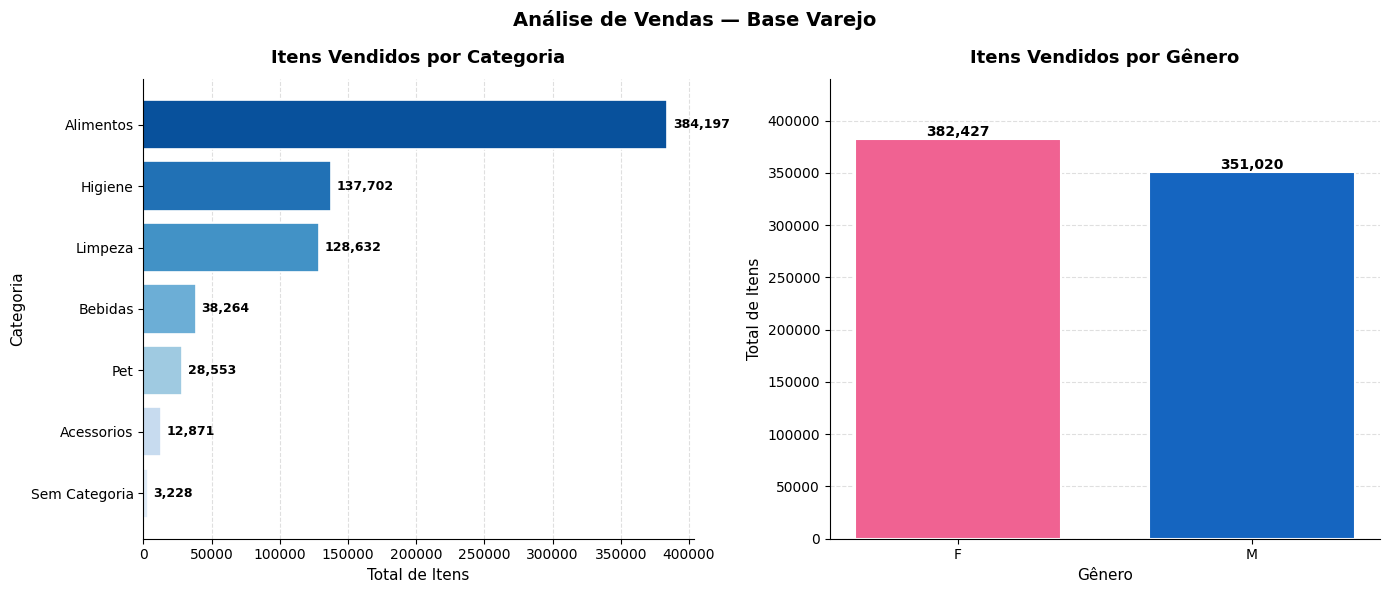

Gráfico salvo em: grafico_vendas.png


In [7]:
print("\n" + "=" * 60)
print("BLOCO 6 — VISUALIZAÇÕES")
print("=" * 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Análise de Vendas — Base Varejo', fontsize=14, fontweight='bold')

cor_categoria = sns.color_palette('Blues_r', n_colors=len(vendas_categoria))
cor_genero = ['#F06292', '#1565C0'] 

# ── Gráfico 1: Itens Vendidos por Categoria (barras horizontais) ──
barras_cat = ax1.barh(
    vendas_categoria['PR_CAT'],
    vendas_categoria['total_itens'],
    color=cor_categoria,
    edgecolor='white',
    linewidth=1.2
)

ax1.invert_yaxis()  # maior valor no topo
ax1.set_title('Itens Vendidos por Categoria', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Total de Itens', fontsize=11)
ax1.set_ylabel('Categoria', fontsize=11)

# Rótulos de valor ao lado de cada barra
for barra in barras_cat:
    largura = barra.get_width()
    ax1.text(
        largura + 4000,
        barra.get_y() + barra.get_height() / 2,
        f'{largura:,.0f}',
        va='center', fontsize=9, fontweight='bold'
    )

ax1.xaxis.grid(True, linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Gráfico 2: Itens Vendidos por Gênero (barras verticais) ──
barras_gen = ax2.bar(
    compras_genero['CL_GENERO'],
    compras_genero['total_itens'],
    color=cor_genero,
    width=0.7,
    edgecolor='white',
    linewidth=1.5
)

ax2.set_title('Itens Vendidos por Gênero', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Gênero', fontsize=11)
ax2.set_ylabel('Total de Itens', fontsize=11)
ax2.set_ylim(0, max(compras_genero['total_itens']) * 1.15)

# Rótulos de valor em cima de cada barra
for barra in barras_gen:
    altura = barra.get_height()
    ax2.text(
        barra.get_x() + barra.get_width() / 2, altura + 3000,
        f'{altura:,.0f}',
        ha='center', fontsize=10, fontweight='bold'
    )

ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/grafico_vendas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em: grafico_vendas.png")

---
## ✅ Conclusão

In [8]:
print("\n" + "=" * 60)
print("ANÁLISE CONCLUÍDA")
print("=" * 60)
print("Consulte o arquivo README.md para os insights e conclusões.")
print("=" * 60)


ANÁLISE CONCLUÍDA
Consulte o arquivo README.md para os insights e conclusões.
